In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("owid-covid-data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (44785, 41)

First 5 rows:


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [7]:
print("Dataset Info:")
print("-" * 50)
print(df.info())

print("\nBasic Statistics:")
print("-" * 50)
print(df.describe())

print("\nColumn Names:")
print("-" * 50)
print(df.columns.tolist())

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_m

In [9]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percentage
}).sort_values('Percentage', ascending=False)

print("Missing Values Analysis:")
print("-" * 50)
print(missing_df[missing_df['Missing_Count'] > 0].head(20))

Missing Values Analysis:
--------------------------------------------------
                                 Missing_Count  Percentage
new_tests                                29138   65.061963
new_tests_per_thousand                   29138   65.061963
total_tests                              28763   64.224629
total_tests_per_thousand                 28763   64.224629
tests_per_case                           28636   63.941052
positive_rate                            28252   63.083622
new_tests_smoothed                       27217   60.772580
new_tests_smoothed_per_thousand          27217   60.772580
tests_units                              26411   58.972870
handwashing_facilities                   26127   58.338729
extreme_poverty                          18463   41.225857
male_smokers                             13822   30.863012
female_smokers                           13427   29.981020
hospital_beds_per_thousand                8646   19.305571
stringency_index                       

In [11]:
important_cols = [
    'location', 'date', 'total_cases', 'new_cases',
    'total_deaths', 'new_deaths',
    'population', 'continent'
]

df_clean = df[important_cols].copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean = df_clean.fillna(0)

df_clean = df_clean.sort_values(['location', 'date'])

print("Cleaned Dataset Info:")
print("-" * 50)
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Date Range: {df_clean['date'].min()} to {df_clean['date'].max()}")
df_clean.head()

Cleaned Dataset Info:
--------------------------------------------------
Rows: 44785
Columns: 8
Date Range: 2019-12-31 00:00:00 to 2020-09-19 00:00:00


,location,date,total_cases,new_cases,total_deaths,new_deaths,population,continent
0,Afghanistan,2019-12-31,0.0,0.0,0.0,0.0,38928341.0,Asia
1,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,38928341.0,Asia
2,Afghanistan,2020-01-02,0.0,0.0,0.0,0.0,38928341.0,Asia
3,Afghanistan,2020-01-03,0.0,0.0,0.0,0.0,38928341.0,Asia
4,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0,38928341.0,Asia


In [13]:
latest_date = df_clean['date'].max()
latest_data = df_clean[df_clean['date'] == latest_date].copy()

latest_data = latest_data[
    (~latest_data['location'].isin(['World', 'International'])) &
    (latest_data['continent'] != '')
]

top_countries_cases = latest_data.nlargest(20, 'total_cases')[['location', 'total_cases', 'total_deaths', 'population']]

print(f"Latest Data Date: {latest_date}")
print("\nTop 20 Countries by Total Cases:")
print("-" * 60)
top_countries_cases

Latest Data Date: 2020-09-19 00:00:00

Top 20 Countries by Total Cases:
------------------------------------------------------------


,location,total_cases,total_deaths,population
42376,United States,6724667.0,198589.0,3.310026e+08
18959,India,5308014.0,85619.0,1.380004e+09
6025,Brazil,4495183.0,135793.0,2.125594e+08
33573,Russia,1091186.0,19195.0,1.459345e+08
31940,Peru,756412.0,31283.0,3.297185e+07
9074,Colombia,750471.0,23850.0,5.088288e+07
26596,Mexico,688954.0,72803.0,1.289328e+08
36982,South Africa,657627.0,15857.0,5.930869e+07
1683,Argentina,601700.0,12491.0,4.519578e+07
8611,Chile,442827.0,12199.0,1.911621e+07


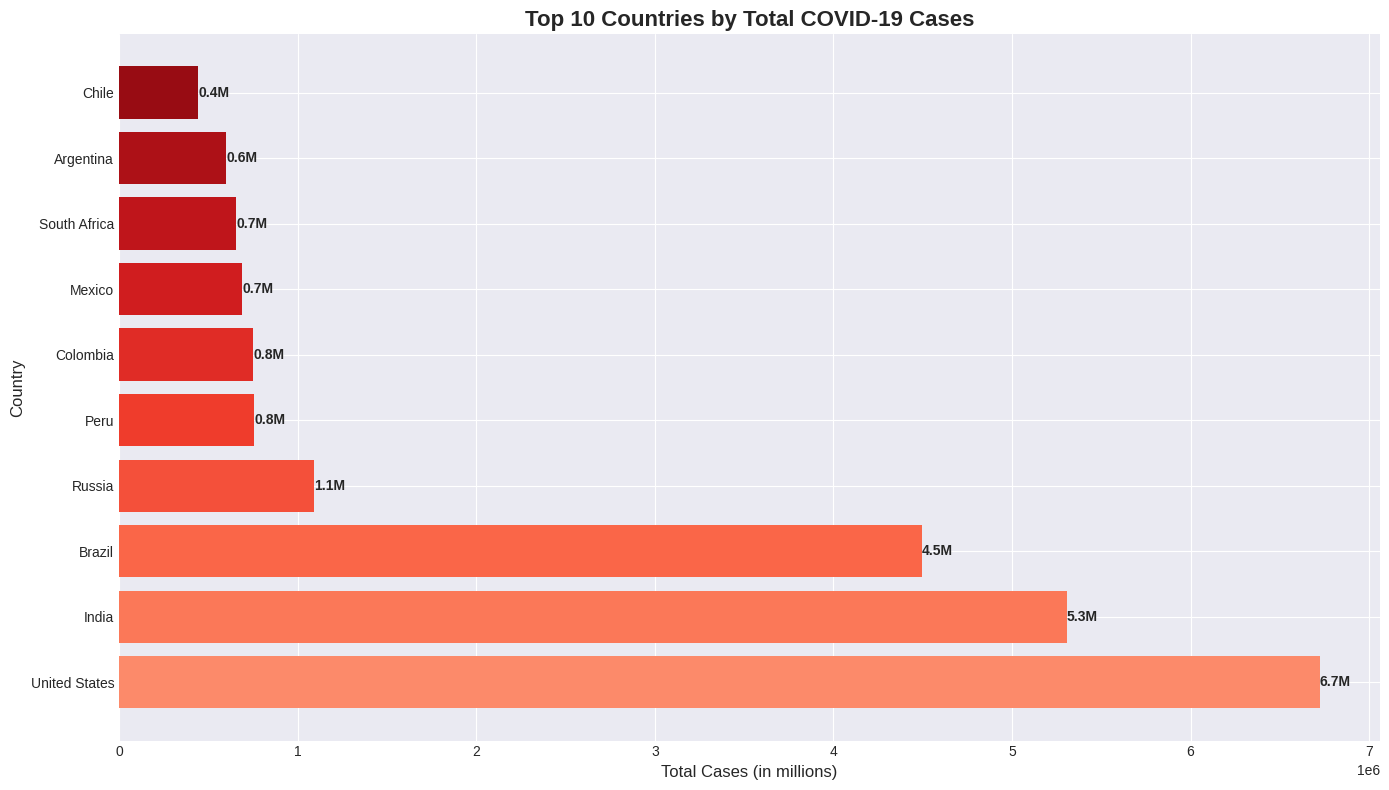

In [14]:
plt.figure(figsize=(14, 8))

top10_cases = top_countries_cases.head(10)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))

bars = plt.barh(top10_cases['location'], top10_cases['total_cases'], color=colors)
plt.xlabel('Total Cases (in millions)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=16, fontweight='bold')

for i, (bar, value) in enumerate(zip(bars, top10_cases['total_cases'])):
    plt.text(value, bar.get_y() + bar.get_height()/2,
             f'{value/1e6:.1f}M',
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

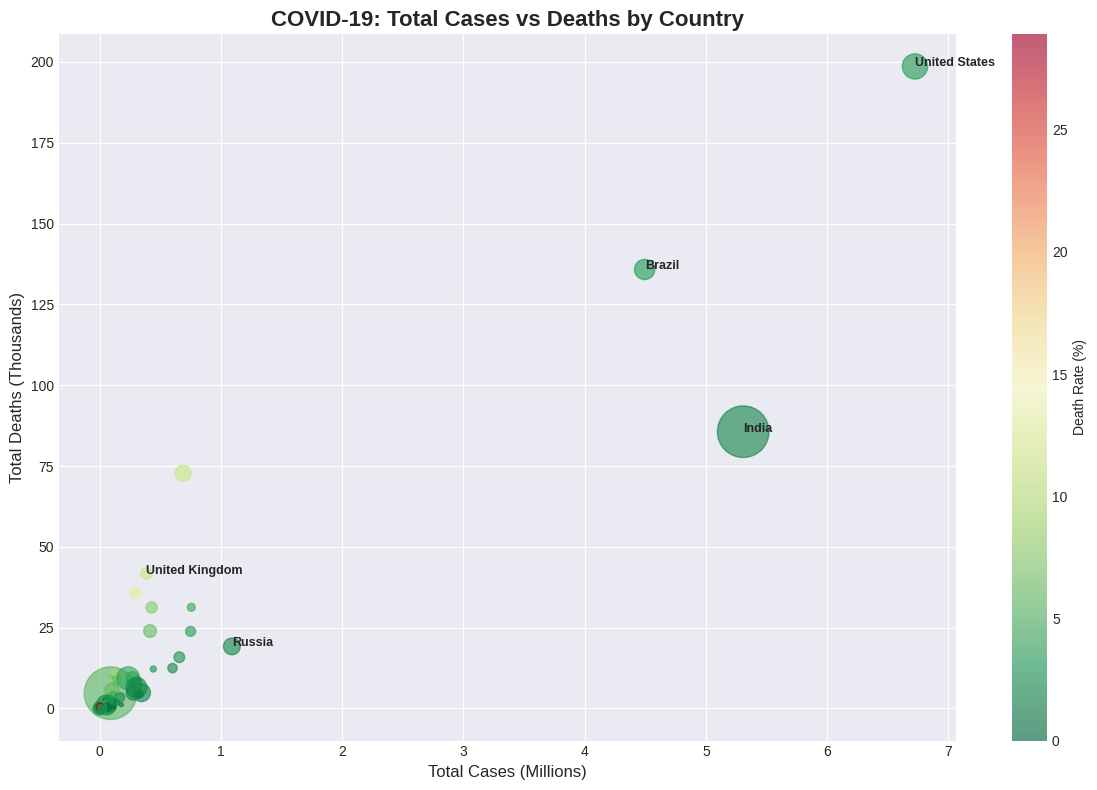

In [15]:
plt.figure(figsize=(12, 8))

latest_data['death_rate'] = (latest_data['total_deaths'] / latest_data['total_cases']) * 100

scatter = plt.scatter(latest_data['total_cases']/1e6,
                     latest_data['total_deaths']/1e3,
                     c=latest_data['death_rate'],
                     s=latest_data['population']/1e6,
                     alpha=0.6,
                     cmap='RdYlGn_r')

plt.colorbar(scatter, label='Death Rate (%)')
plt.xlabel('Total Cases (Millions)', fontsize=12)
plt.ylabel('Total Deaths (Thousands)', fontsize=12)
plt.title('COVID-19: Total Cases vs Deaths by Country', fontsize=16, fontweight='bold')

major_countries = ['United States', 'India', 'Brazil', 'Russia', 'United Kingdom']
for country in major_countries:
    country_data = latest_data[latest_data['location'] == country]
    if not country_data.empty:
        plt.annotate(country,
                    (country_data['total_cases'].values[0]/1e6,
                     country_data['total_deaths'].values[0]/1e3),
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
selected_countries = ['United States', 'India', 'Brazil', 'United Kingdom', 'Japan', 'South Africa']

ts_data = df_clean[df_clean['location'].isin(selected_countries)]

print("Time Series Data for Selected Countries:")
print(f"Countries: {selected_countries}")
print(f"Date Range: {ts_data['date'].min()} to {ts_data['date'].max()}")
print(f"Total Records: {len(ts_data)}")

Time Series Data for Selected Countries:
Countries: ['United States', 'India', 'Brazil', 'United Kingdom', 'Japan', 'South Africa']
Date Range: 2019-12-31 00:00:00 to 2020-09-19 00:00:00
Total Records: 1546


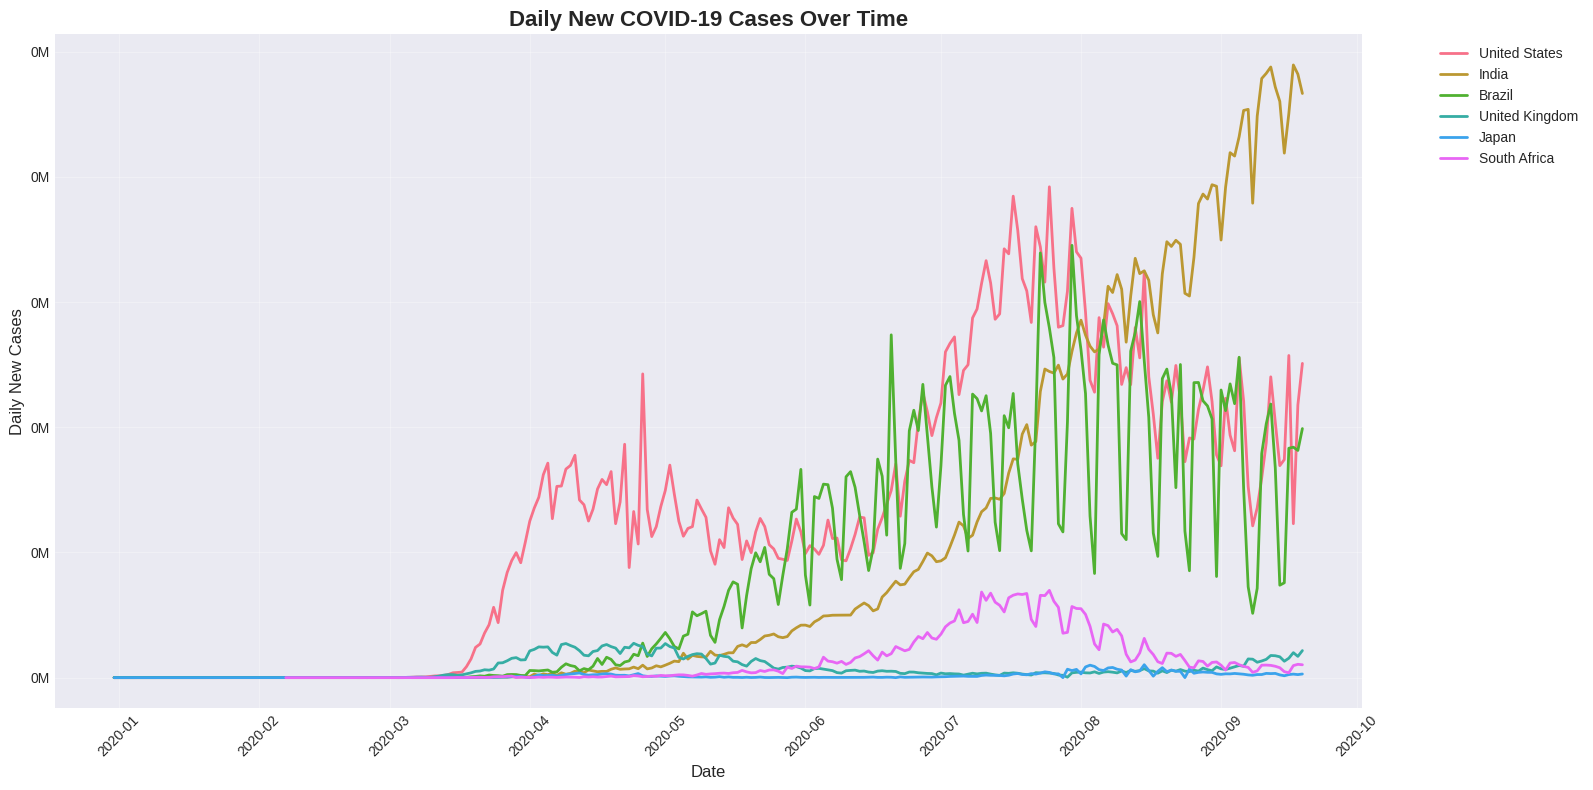

In [17]:
plt.figure(figsize=(16, 8))

for country in selected_countries:
    country_data = ts_data[ts_data['location'] == country]
    plt.plot(country_data['date'], country_data['new_cases'],
             label=country, linewidth=2)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily New Cases', fontsize=12)
plt.title('Daily New COVID-19 Cases Over Time', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x/1e6), '') + 'M'))

plt.tight_layout()
plt.show()

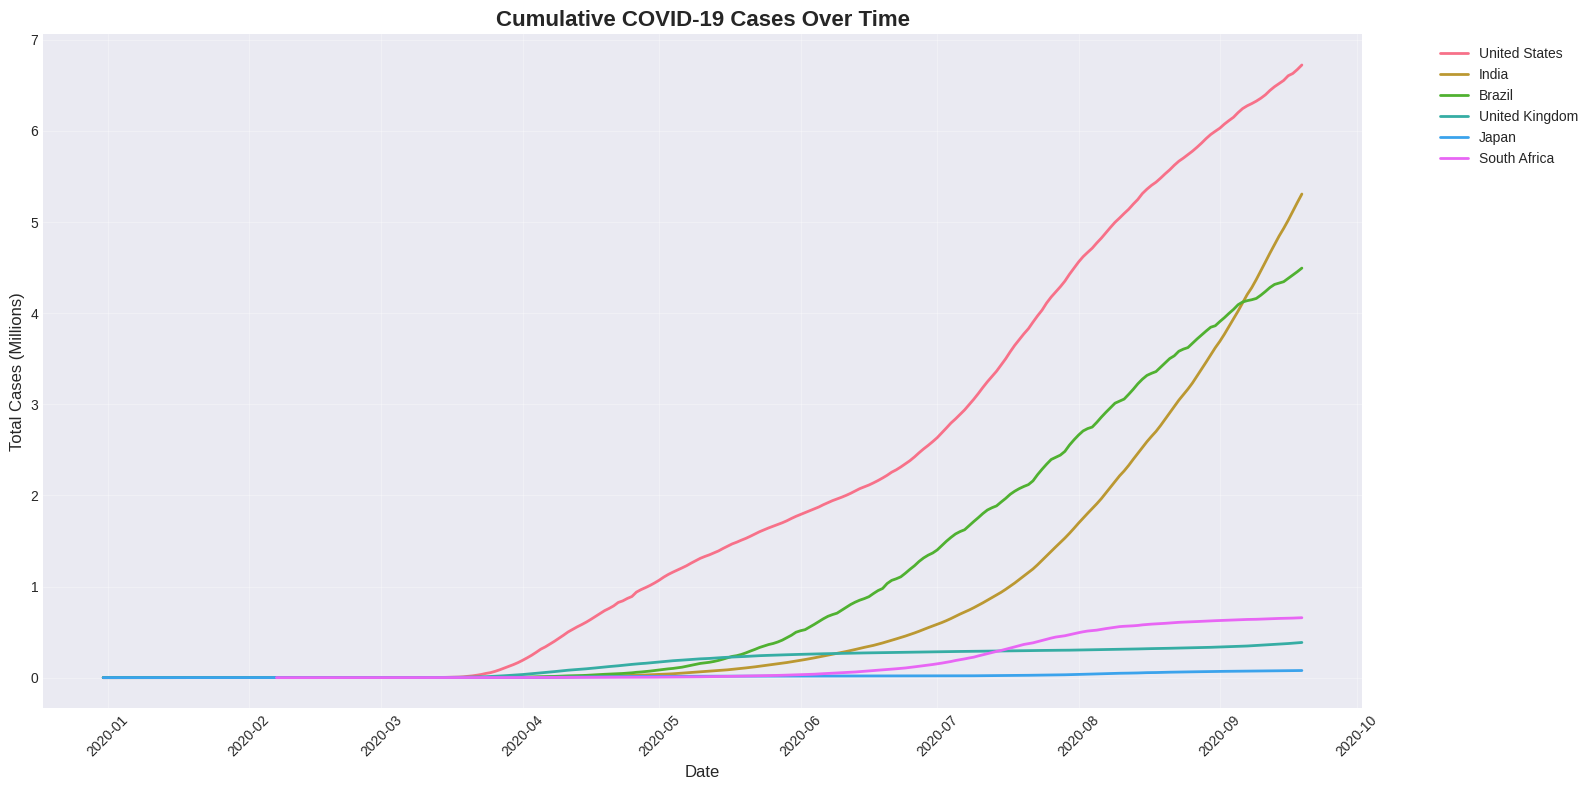

In [18]:
plt.figure(figsize=(16, 8))

for country in selected_countries:
    country_data = ts_data[ts_data['location'] == country]
    plt.plot(country_data['date'], country_data['total_cases']/1e6,
             label=country, linewidth=2)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Cases (Millions)', fontsize=12)
plt.title('Cumulative COVID-19 Cases Over Time', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

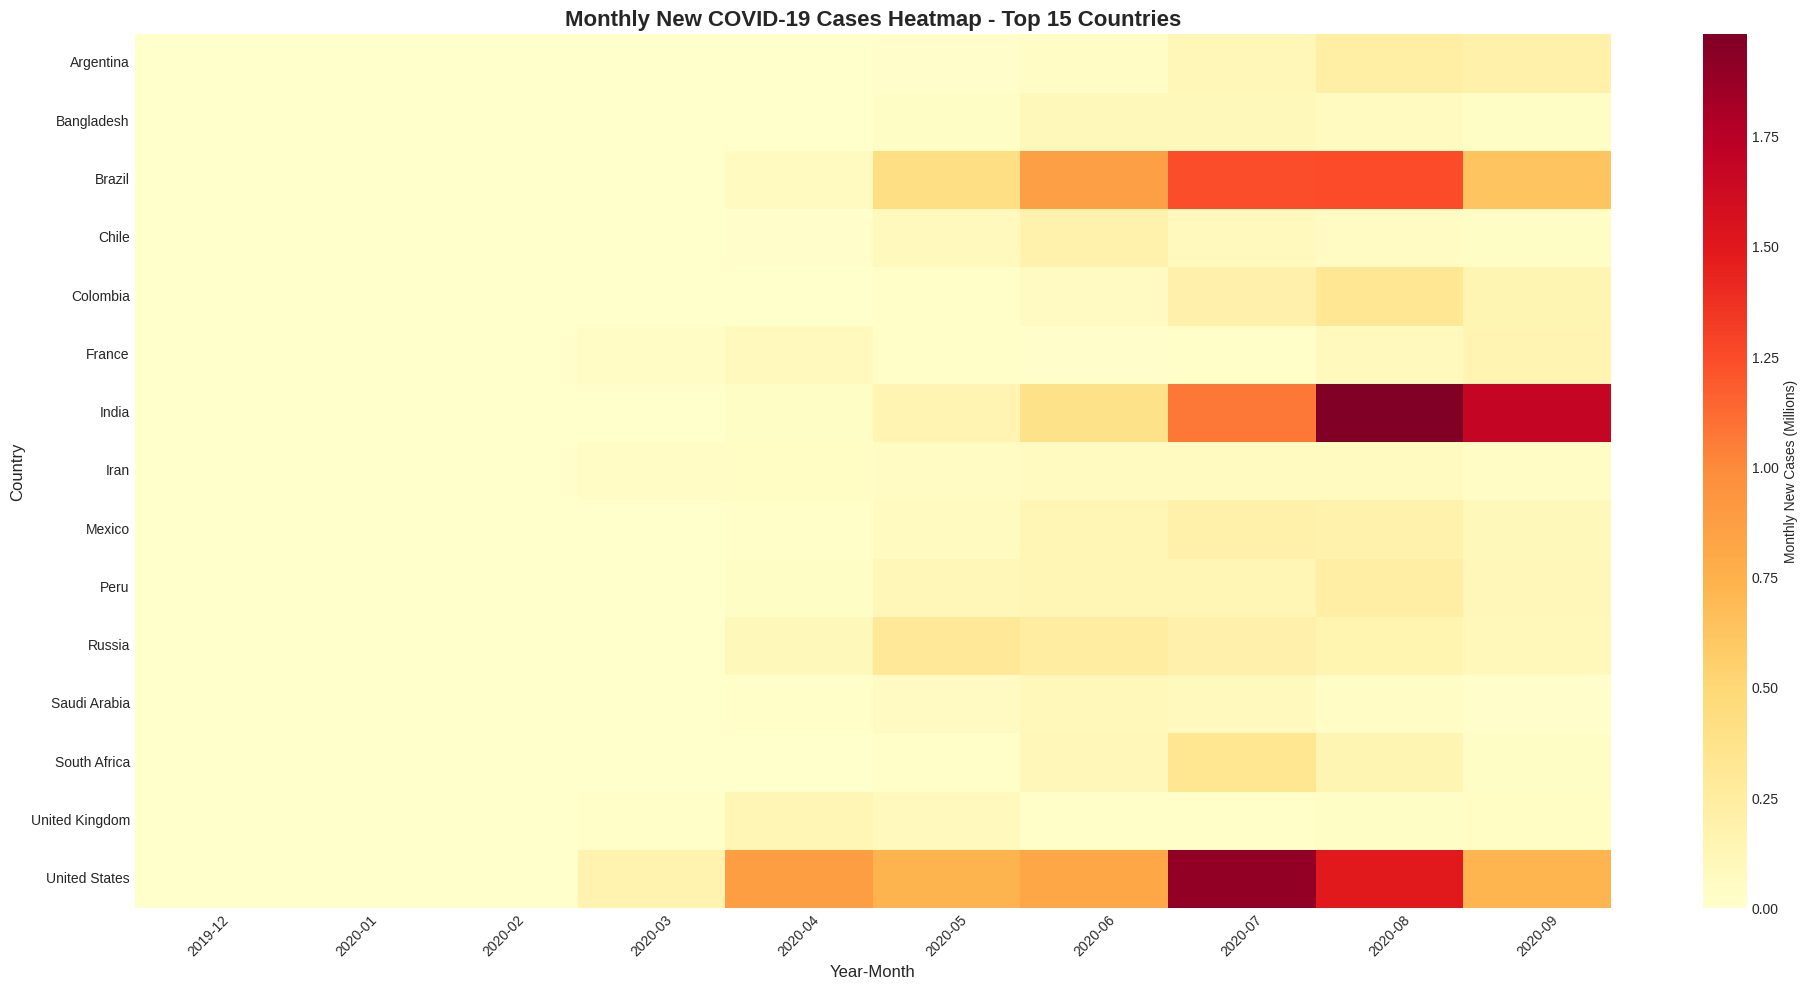

In [19]:
monthly_data = df_clean.copy()
monthly_data['year_month'] = monthly_data['date'].dt.to_period('M')

top15_countries = latest_data.nlargest(15, 'total_cases')['location'].tolist()

heatmap_data = monthly_data[monthly_data['location'].isin(top15_countries)]
heatmap_pivot = heatmap_data.pivot_table(
    values='new_cases',
    index='location',
    columns='year_month',
    aggfunc='sum'
)

heatmap_pivot = heatmap_pivot.fillna(0)

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_pivot/1e6, cmap='YlOrRd', annot=False,
            cbar_kws={'label': 'Monthly New Cases (Millions)'})
plt.title('Monthly New COVID-19 Cases Heatmap - Top 15 Countries', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
if 'total_vaccinations' in df_clean.columns:

    latest_vacc = df_clean[df_clean['date'] == latest_date].copy()
    latest_vacc = latest_vacc[latest_vacc['total_vaccinations'] > 0]
    latest_vacc = latest_vacc.nlargest(15, 'total_vaccinations')

    latest_vacc['vaccination_rate'] = (latest_vacc['people_vaccinated'] / latest_vacc['population']) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(latest_vacc['location'], latest_vacc['total_vaccinations']/1e6, color='skyblue')
    axes[0].set_xlabel('Total Vaccinations (Millions)')
    axes[0].set_title('Top 15 Countries by Total Vaccinations')

    axes[1].barh(latest_vacc['location'], latest_vacc['vaccination_rate'], color='lightgreen')
    axes[1].set_xlabel('Vaccination Rate (%)')
    axes[1].set_title('Vaccination Rate (% of Population)')

    plt.tight_layout()
    plt.show()

    print("\nTop 10 Countries by Vaccination Rate:")
    print(latest_vacc[['location', 'vaccination_rate']].head(10).to_string(index=False))
else:
    print("Vaccination data not available in this dataset")

Vaccination data not available in this dataset


In [21]:
continent_data = df_clean[df_clean['continent'].notna()].copy()
continent_latest = continent_data[continent_data['date'] == latest_date]

continent_summary = continent_latest.groupby('continent').agg({
    'total_cases': 'sum',
    'total_deaths': 'sum',
    'population': 'sum'
}).reset_index()

continent_summary['death_rate'] = (continent_summary['total_deaths'] / continent_summary['total_cases']) * 100
continent_summary['cases_per_million'] = (continent_summary['total_cases'] / continent_summary['population']) * 1e6

print("Continent-wise COVID-19 Statistics:")
print("-" * 60)
continent_summary

Continent-wise COVID-19 Statistics:
------------------------------------------------------------


,continent,total_cases,total_deaths,population,death_rate,cases_per_million
0,0,30541142.0,952731.0,7.794799e+09,3.119500,3918.143760
1,Africa,1391241.0,33623.0,1.339424e+09,2.416763,1038.686093
2,Asia,9266887.0,173921.0,4.599891e+09,1.876801,2014.588348
3,Europe,3712416.0,185266.0,7.017514e+08,4.990443,5290.215106
4,North America,8090185.0,292949.0,5.912425e+08,3.621042,13683.362359
5,Oceania,32211.0,908.0,4.095832e+07,2.818913,786.433623
6,South America,7406770.0,235555.0,4.304611e+08,3.180266,17206.595839


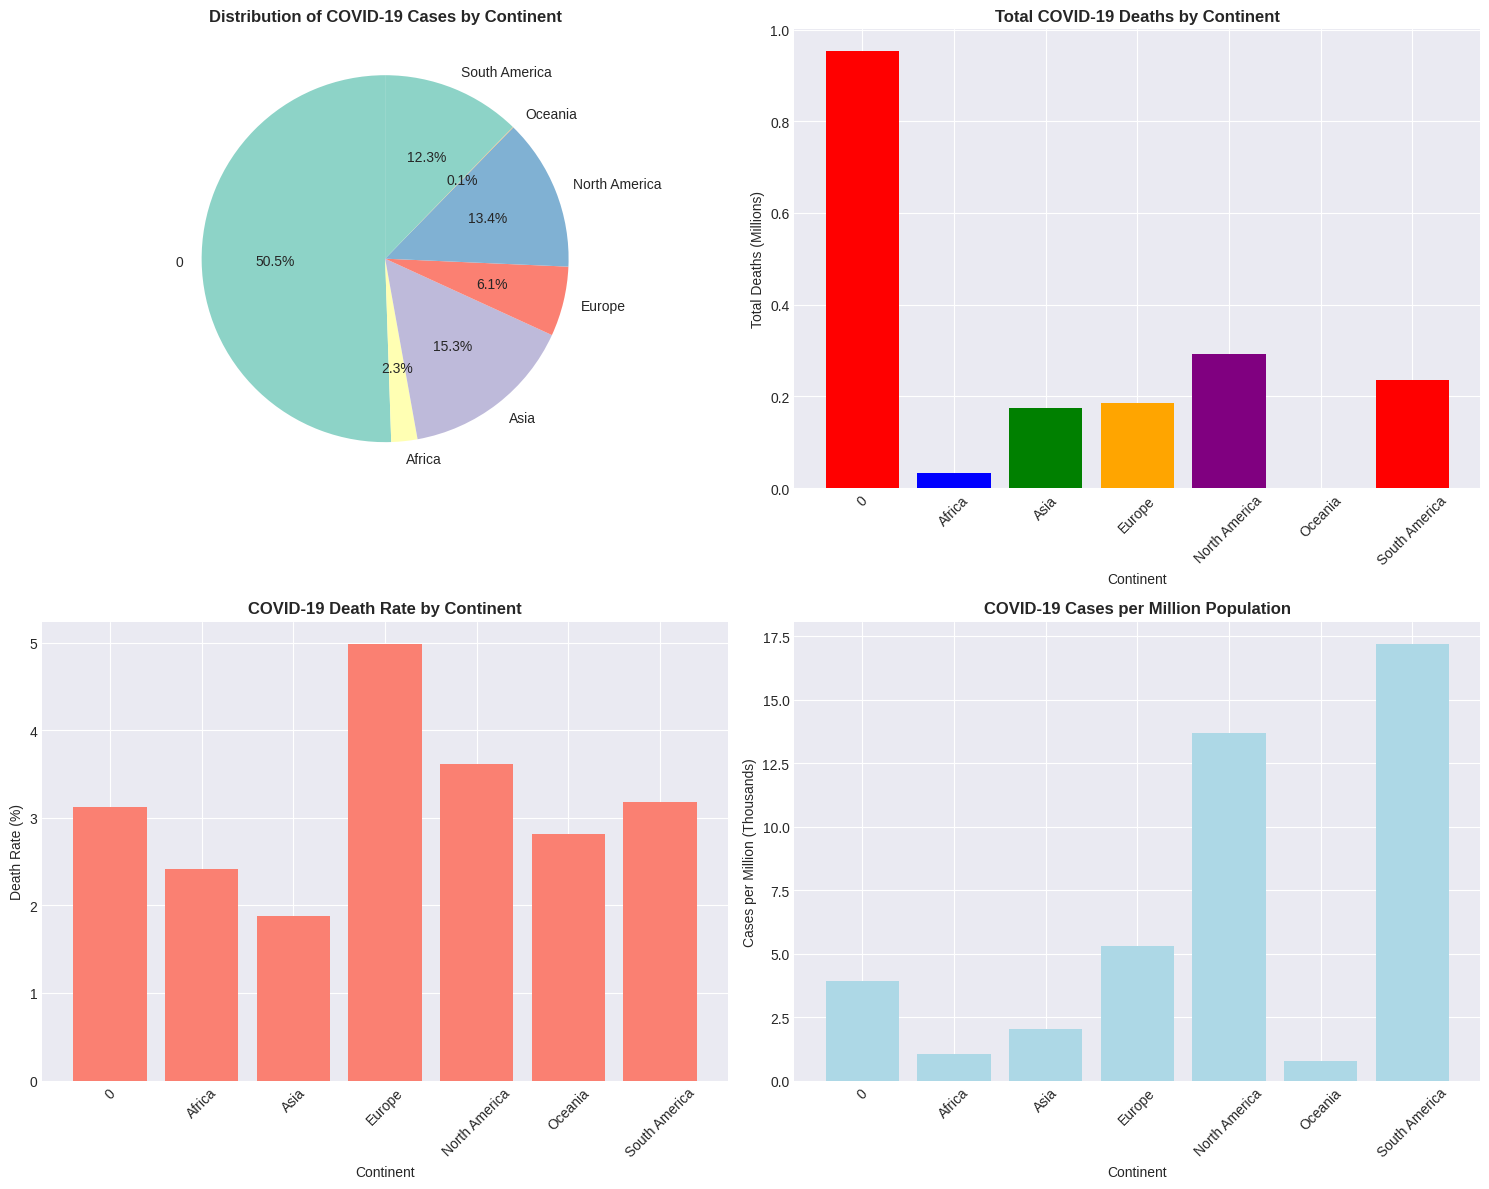

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].pie(continent_summary['total_cases'], labels=continent_summary['continent'],
               autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(range(6))
)
axes[0, 0].set_title('Distribution of COVID-19 Cases by Continent', fontweight='bold')

x_pos = np.arange(len(continent_summary['continent']))
axes[0, 1].bar(x_pos, continent_summary['total_deaths']/1e6,
               color=['red', 'blue', 'green', 'orange', 'purple', 'brown']
)
axes[0, 1].set_xlabel('Continent')
axes[0, 1].set_ylabel('Total Deaths (Millions)')
axes[0, 1].set_title('Total COVID-19 Deaths by Continent', fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(continent_summary['continent'], rotation=45)

x_pos = np.arange(len(continent_summary['continent']))
axes[1, 0].bar(x_pos, continent_summary['death_rate'],
               color='salmon'
)
axes[1, 0].set_xlabel('Continent')
axes[1, 0].set_ylabel('Death Rate (%)')
axes[1, 0].set_title('COVID-19 Death Rate by Continent', fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(continent_summary['continent'], rotation=45)

x_pos = np.arange(len(continent_summary['continent']))
axes[1, 1].bar(x_pos, continent_summary['cases_per_million']/1000,
               color='lightblue'
)
axes[1, 1].set_xlabel('Continent')
axes[1, 1].set_ylabel('Cases per Million (Thousands)')
axes[1, 1].set_title('COVID-19 Cases per Million Population', fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(continent_summary['continent'], rotation=45)

plt.tight_layout()
plt.show()

In [23]:
growth_analysis = ts_data.copy()
growth_analysis['growth_rate'] = growth_analysis.groupby('location')['new_cases'].pct_change() * 100

latest_30_days = growth_analysis[growth_analysis['date'] > (growth_analysis['date'].max() - pd.Timedelta(days=30))]

avg_growth = latest_30_days.groupby('location')['growth_rate'].mean().reset_index()
avg_growth = avg_growth.dropna()

print("Average Daily Growth Rate (Last 30 Days):")
print("-" * 50)
for index, row in avg_growth.iterrows():
    print(f"{row['location']}: {row['growth_rate']:.2f}%")

Average Daily Growth Rate (Last 30 Days):
--------------------------------------------------
Brazil: 13.53%
India: 1.25%
Japan: 644.29%
South Africa: 4.57%
United Kingdom: 8.06%
United States: 3.26%


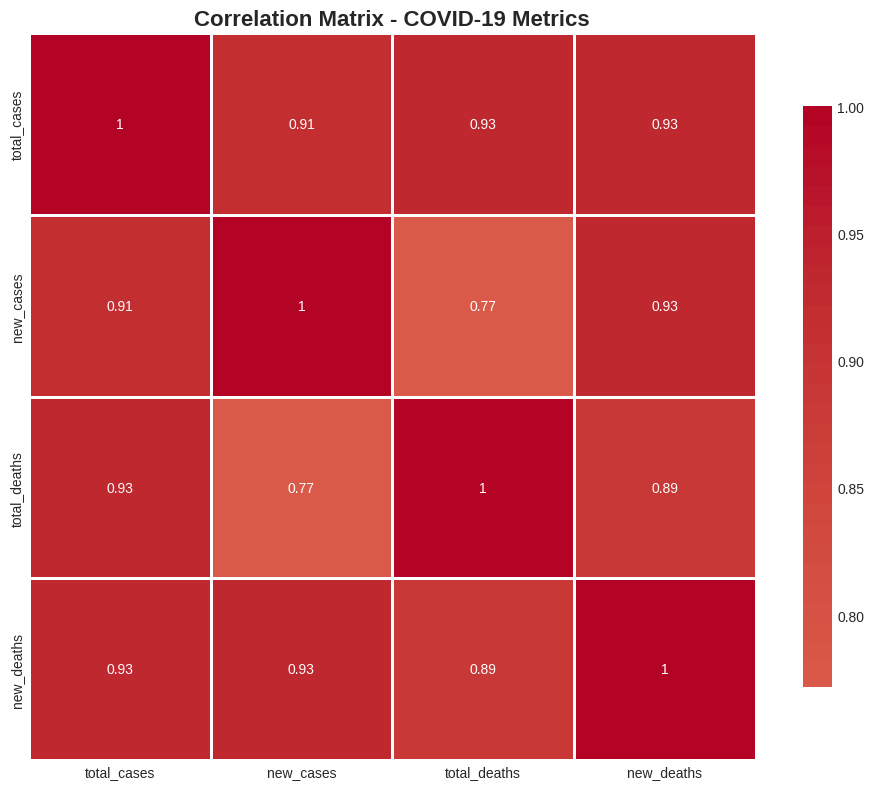

In [25]:
corr_columns = ['total_cases', 'new_cases', 'total_deaths', 'new_deaths']
if 'total_vaccinations' in df_clean.columns:
    corr_columns.extend(['total_vaccinations', 'people_vaccinated'])

corr_data = latest_data[corr_columns].dropna()
correlation_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - COVID-19 Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
print("=" * 70)
print("COVID-19 DATA ANALYSIS SUMMARY")
print("=" * 70)

global_total_cases = df_clean[df_clean['location'] == 'World']['total_cases'].max()
global_total_deaths = df_clean[df_clean['location'] == 'World']['total_deaths'].max()
global_death_rate = (global_total_deaths / global_total_cases) * 100

print(f"\nGLOBAL STATISTICS (as of {latest_date.strftime('%Y-%m-%d')}):")
print("-" * 40)
print(f"Total Cases Worldwide: {global_total_cases:,.0f}")
print(f"Total Deaths Worldwide: {global_total_deaths:,.0f}")
print(f"Global Death Rate: {global_death_rate:.2f}%")

print(f"\nTOP 5 COUNTRIES BY TOTAL CASES:")
print("-" * 40)
for idx, row in top_countries_cases.head(5).iterrows():
    death_rate = (row['total_deaths'] / row['total_cases']) * 100 if row['total_cases'] > 0 else 0
    print(f"{row['location']}: {row['total_cases']:,.0f} cases, {death_rate:.2f}% death rate")

print(f"\nCOUNTRIES WITH HIGHEST DEATH RATE (>5%):")
print("-" * 40)
high_death_rate = latest_data[latest_data['total_cases'] > 100000].nlargest(10, 'death_rate')[['location', 'death_rate']]
for idx, row in high_death_rate.iterrows():
    print(f"{row['location']}: {row['death_rate']:.2f}%")

COVID-19 DATA ANALYSIS SUMMARY

GLOBAL STATISTICS (as of 2020-09-19):
----------------------------------------
Total Cases Worldwide: 30,540,446
Total Deaths Worldwide: 952,724
Global Death Rate: 3.12%

TOP 5 COUNTRIES BY TOTAL CASES:
----------------------------------------
United States: 6,724,667 cases, 2.95% death rate
India: 5,308,014 cases, 1.61% death rate
Brazil: 4,495,183 cases, 3.02% death rate
Russia: 1,091,186 cases, 1.76% death rate
Peru: 756,412 cases, 4.14% death rate

COUNTRIES WITH HIGHEST DEATH RATE (>5%):
----------------------------------------
Italy: 12.09%
United Kingdom: 10.81%
Mexico: 10.57%
Ecuador: 8.90%
France: 7.29%
Canada: 6.49%
Bolivia: 5.81%
Iran: 5.75%
Egypt: 5.63%
Peru: 4.14%


In [27]:
output_file = 'covid19_analysis_results.csv'

summary_data = {
    'Metric': ['Total Global Cases', 'Total Global Deaths', 'Global Death Rate',
               'Number of Countries Analyzed', 'Date Range Start', 'Date Range End'],
    'Value': [f"{global_total_cases:,.0f}",
              f"{global_total_deaths:,.0f}",
              f"{global_death_rate:.2f}%",
              f"{len(latest_data)}",
              df_clean['date'].min().strftime('%Y-%m-%d'),
              df_clean['date'].max().strftime('%Y-%m-%d')]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(output_file, index=False)

print(f"Summary data saved to: {output_file}")
print("\nAnalysis complete! 🎉")

Summary data saved to: covid19_analysis_results.csv

Analysis complete! 🎉


In [28]:
try:

    fig = px.choropleth(latest_data,
                        locations='location',
                        locationmode='country names',
                        color='total_cases',
                        hover_name='location',
                        hover_data={'total_cases': True, 'total_deaths': True, 'population': True},
                        color_continuous_scale='Reds',
                        title='World Map: Total COVID-19 Cases by Country',
                        labels={'total_cases': 'Total Cases'})

    fig.update_layout(title_font_size=20, title_x=0.5)
    fig.show()

except Exception as e:
    print(f"Interactive map could not be displayed: {e}")
    print("This is optional - your analysis is still complete!")